# Orthomosaic tiling for ML (RGB)

This notebook:
1. Selects an orthomosaic GeoTIFF
2. Computes coverage area and saves/displays a quicklook PNG
3. Tiles the valid (non-black / non-nodata) region into fixed-size tiles with overlap
4. Skips mostly-empty tiles and writes per-tile JSON metadata


In [1]:
# 0 — Imports

from pathlib import Path
import json
import random

import numpy as np
import rasterio
from rasterio.windows import Window
from rasterio.windows import transform as window_transform
from rasterio.enums import Resampling

# Optional (for display and PNG saving)
try:
    import matplotlib.pyplot as plt
except Exception:
    plt = None

try:
    from PIL import Image
except Exception:
    Image = None


In [2]:
# 1 — Select an ortho (works in VS Code / Jupyter / terminal)

ORTHO_FOLDER = Path("./data_set/orthomosaic")
OUT_ROOT     = Path("./output/tiles_out")   # tiles will be saved under OUT_ROOT/<ortho_stem>/

def pick_ortho(folder: Path) -> Path:
    tifs = sorted(list(folder.glob("*.tif"))) + sorted(list(folder.glob("*.tiff")))
    if not tifs:
        raise FileNotFoundError(f"No .tif/.tiff files found in: {folder.resolve()}")

    print("\nAvailable ortho files:")
    for i, p in enumerate(tifs, 1):
        print(f"{i:2d}) {p.name}")

    choice = int(input("\nSelect a file number: ").strip())
    if choice < 1 or choice > len(tifs):
        raise ValueError("Invalid selection.")
    return tifs[choice - 1]

ORTHO_PATH = pick_ortho(ORTHO_FOLDER)

# Output folder associated with the selected ortho
OUT_DIR = OUT_ROOT / ORTHO_PATH.stem
(OUT_DIR / "images").mkdir(parents=True, exist_ok=True)
(OUT_DIR / "meta").mkdir(exist_ok=True)
(OUT_DIR / "qc").mkdir(exist_ok=True)

print("\nSelected:")
print("ORTHO_PATH =", ORTHO_PATH)
print("OUT_DIR    =", OUT_DIR)



Available ortho files:
 1) A10Segment1.tif
 2) A10Segment1_resampled.tif
 3) A58Segment2.tif
 4) A58Segment2_roadside.tif
 5) G15Segment1.tif



Select a file number:  5



Selected:
ORTHO_PATH = data_set/orthomosaic/G15Segment1.tif
OUT_DIR    = output/tiles_out/G15Segment1


In [9]:
import shutil

def reset_output_folder(out_dir: Path):
    """
    Completely clears the output folder (images + meta + qc).
    Creates fresh empty folders.
    """
    if out_dir.exists():
        shutil.rmtree(out_dir)

    (out_dir / "images").mkdir(parents=True, exist_ok=True)
    (out_dir / "meta").mkdir(parents=True, exist_ok=True)
    (out_dir / "qc").mkdir(parents=True, exist_ok=True)

    print(f"Output folder reset: {out_dir}")

In [10]:
# 2 — User settings for tiling

TILE_SIZE  = 512
OVERLAP    = 128
BANDS      = (1, 2, 3)          # RGB (1-based indices)

# Skip tiles where invalid (black/nodata) fraction >= this.
# For irregular orthos, 0.60–0.80 is a good range.
SKIP_INVALID_FRACTION = 0.70

# If nodata isn't set, treat near-black pixels as invalid.
BLACK_THRESH_U8  = 5
BLACK_THRESH_U16 = int(0.01 * 65535)

# For speed: compute valid bbox from downsampled mask
MASK_MAX_SIDE = 2000

# Output format for tiles
OUTPUT_FORMAT = "png"  # "png" or "geotiff"

print("Config OK")


Config OK


In [11]:
# 3 — Helper functions (bbox, quicklook, tiling utilities)

def compute_valid_bbox(src: rasterio.io.DatasetReader,
                       mask_max_side: int = 2000,
                       black_thr_u8: int = 5,
                       black_thr_u16: int = int(0.01 * 65535)) -> tuple[int, int, int, int]:
    """Return (x0, y0, x1, y1) bbox in full-res pixel coords covering valid pixels.

    Uses a downsampled read of band 1 for speed.
    """
    w, h = src.width, src.height
    scale = max(w, h) / mask_max_side
    if scale < 1:
        scale = 1

    out_w = max(1, int(w / scale))
    out_h = max(1, int(h / scale))

    band1 = src.read(1, out_shape=(out_h, out_w), resampling=Resampling.nearest)

    dtype = str(src.dtypes[0]) if src.dtypes else "uint8"
    thr = black_thr_u16 if "uint16" in dtype else black_thr_u8

    if src.nodata is not None:
        valid_small = band1 != src.nodata
    else:
        valid_small = band1 > thr

    if not np.any(valid_small):
        raise ValueError("No valid pixels found. Check nodata/black threshold.")

    rows = np.any(valid_small, axis=1)
    cols = np.any(valid_small, axis=0)

    y0_s, y1_s = np.where(rows)[0][[0, -1]]
    x0_s, x1_s = np.where(cols)[0][[0, -1]]

    x0 = int(np.floor(x0_s * scale))
    y0 = int(np.floor(y0_s * scale))
    x1 = int(np.ceil((x1_s + 1) * scale))
    y1 = int(np.ceil((y1_s + 1) * scale))

    # Clamp to raster size
    x0 = max(0, min(x0, w))
    y0 = max(0, min(y0, h))
    x1 = max(0, min(x1, w))
    y1 = max(0, min(y1, h))

    return x0, y0, x1, y1


def invalid_fraction(tile_chw: np.ndarray, nodata=None,
                     thr_u8: int = 5, thr_u16: int = int(0.01 * 65535)) -> float:
    """tile_chw: (C,H,W). Returns fraction of invalid pixels."""
    t = np.transpose(tile_chw, (1, 2, 0))  # HWC

    if nodata is not None:
        inv = np.any(t == nodata, axis=2)
    else:
        thr = thr_u16 if tile_chw.dtype == np.uint16 else thr_u8
        inv = np.all(t <= thr, axis=2)

    return float(inv.mean())


def to_uint8_rgb(tile_chw: np.ndarray) -> np.ndarray:
    """Convert (C,H,W) to uint8 (C,H,W) using robust per-band stretch."""
    if tile_chw.dtype == np.uint8:
        return tile_chw

    out = np.zeros_like(tile_chw, dtype=np.uint8)
    for b in range(tile_chw.shape[0]):
        band = tile_chw[b].astype(np.float32)
        lo = np.percentile(band, 2)
        hi = np.percentile(band, 98)
        if hi <= lo:
            hi = lo + 1.0
        band_n = (band - lo) / (hi - lo)
        band_n = np.clip(band_n, 0, 1)
        out[b] = (band_n * 255).round().astype(np.uint8)
    return out


def save_png(tile_chw: np.ndarray, out_path: Path):
    """Save tile (C,H,W) as PNG."""
    if Image is None:
        raise ImportError("Pillow not found. Install it: pip install pillow")

    arr8 = to_uint8_rgb(tile_chw)
    hwc = np.transpose(arr8, (1, 2, 0))
    Image.fromarray(hwc).save(out_path)


def save_geotiff(tile_chw: np.ndarray, out_path: Path, src_profile: dict, tform):
    profile = src_profile.copy()
    profile.update(
        driver="GTiff",
        height=tile_chw.shape[1],
        width=tile_chw.shape[2],
        transform=tform,
        count=tile_chw.shape[0],
        compress="deflate",
        tiled=False,
    )
    with rasterio.open(out_path, "w", **profile) as dst:
        dst.write(tile_chw)


def make_quicklook(src: rasterio.io.DatasetReader, out_png: Path, max_side: int = 2000) -> np.ndarray:
    """Create and save a quicklook PNG and return it as uint8 HWC for display."""
    w, h = src.width, src.height
    scale = max(w, h) / max_side
    if scale < 1:
        scale = 1
    out_w = max(1, int(w / scale))
    out_h = max(1, int(h / scale))

    rgb = src.read(BANDS, out_shape=(len(BANDS), out_h, out_w), resampling=Resampling.bilinear)
    rgb_u8_chw = to_uint8_rgb(rgb)
    rgb_u8_hwc = np.transpose(rgb_u8_chw, (1, 2, 0))

    if Image is not None:
        Image.fromarray(rgb_u8_hwc).save(out_png)
    else:
        # fallback via rasterio PNG writer
        profile = {"driver": "PNG", "height": rgb_u8_hwc.shape[0], "width": rgb_u8_hwc.shape[1], "count": 3, "dtype": "uint8"}
        with rasterio.open(out_png, "w", **profile) as dst:
            for i in range(3):
                dst.write(rgb_u8_hwc[..., i], i + 1)

    return rgb_u8_hwc


CRS: EPSG:32610
Pixel size (m): (0.00661, 0.00661)
Coverage: 86.6 m × 69.1 m
Area: 5988 m²  (0.60 ha)
Output folder reset: output/tiles_out/G15Segment1
Saved quicklook: output/tiles_out/G15Segment1/qc/quicklook.png


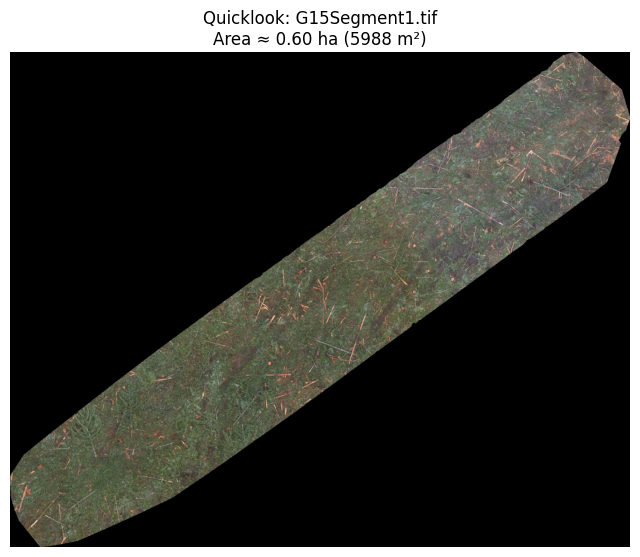

In [12]:
# 4 — Show covered area + display/save ortho quicklook

with rasterio.open(ORTHO_PATH) as src:   
    # Coverage from bounds (UTM meters for your EPSG:32610)
    bounds = src.bounds
    crs = src.crs.to_string() if src.crs else None
    resx, resy = src.res

    width_m  = float(bounds.right - bounds.left)
    height_m = float(bounds.top - bounds.bottom)
    area_m2  = width_m * height_m
    area_ha  = area_m2 / 10_000

    print("CRS:", crs)
    print("Pixel size (m):", (resx, resy))
    print(f"Coverage: {width_m:.1f} m × {height_m:.1f} m")
    print(f"Area: {area_m2:.0f} m²  ({area_ha:.2f} ha)")

    reset_output_folder(OUT_DIR)

    # Quicklook (for QC; not full resolution)
    quicklook_path = OUT_DIR / "qc" / "quicklook.png"
    ql = make_quicklook(src, quicklook_path, max_side=2000)
    print("Saved quicklook:", quicklook_path)

# Display
if plt is not None:
    plt.figure(figsize=(8, 8))
    plt.imshow(ql)
    plt.title(f"Quicklook: {ORTHO_PATH.name}\nArea ≈ {area_ha:.2f} ha ({area_m2:.0f} m²)")
    plt.axis("off")
    plt.show()
else:
    print("matplotlib not available; quicklook saved to disk.")


In [13]:
# 5 — Tile ONLY the valid (irregular) region, skipping mostly-empty tiles

def tile_ortho_irregular(
    ortho_path: Path,
    out_dir: Path,
    tile_size: int,
    overlap: int,
    bands=(1,2,3),
    skip_invalid_fraction: float = 0.70,
):
    step = tile_size - overlap
    if step <= 0:
        raise ValueError("OVERLAP must be smaller than TILE_SIZE.")

    images_dir = out_dir / "images"
    meta_dir = out_dir / "meta"
    images_dir.mkdir(parents=True, exist_ok=True)
    meta_dir.mkdir(parents=True, exist_ok=True)

    tiles_index = []

    
    with rasterio.open(ortho_path) as src:
        x0, y0, x1, y1 = compute_valid_bbox(
            src,
            mask_max_side=MASK_MAX_SIDE,
            black_thr_u8=BLACK_THRESH_U8,
            black_thr_u16=BLACK_THRESH_U16,
        )

        print(f"Valid bbox (pixels): x[{x0},{x1}) y[{y0},{y1})")
        print(f"Tiling step: {step} px  (tile={tile_size}, overlap={overlap})")
        print("Nodata:", src.nodata)
        
        saved = 0
        skipped = 0
        total = 0

        # ---- Tile coverage calculation ----
        pixel_size = src.res[0]  # meters (UTM)
        tile_width_m = tile_size * pixel_size
        tile_area_m2 = tile_width_m ** 2

        print(f"\nTile size (pixels): {tile_size}")
        print(f"Pixel size: {pixel_size:.6f} m")
        print(f"Tile width: {tile_width_m:.2f} m")
        print(f"Tile area: {tile_area_m2:.2f} m²")
        print("-----------------------------------")

        for top in range(y0, y1, step):
            for left in range(x0, x1, step):
                total += 1

                # Keep fixed-size tiles only (better for ML); skip partial edge windows
                if (left + tile_size > src.width) or (top + tile_size > src.height):
                    skipped += 1
                    continue

                win = Window(left, top, tile_size, tile_size)
                tile = src.read(bands, window=win)

                if tile.shape[1] != tile_size or tile.shape[2] != tile_size:
                    skipped += 1
                    continue

                inv = invalid_fraction(tile, nodata=src.nodata,
                                       thr_u8=BLACK_THRESH_U8,
                                       thr_u16=BLACK_THRESH_U16)
                if inv >= skip_invalid_fraction:
                    skipped += 1
                    continue

                tile_id = f"x{left}_y{top}_s{tile_size}"
                if OUTPUT_FORMAT.lower() == "png":
                    out_path = images_dir / f"{tile_id}.png"
                    save_png(tile, out_path)
                elif OUTPUT_FORMAT.lower() == "geotiff":
                    out_path = images_dir / f"{tile_id}.tif"
                    tform = window_transform(win, src.transform)
                    save_geotiff(tile, out_path, src.profile, tform)
                else:
                    raise ValueError("OUTPUT_FORMAT must be 'png' or 'geotiff'")

                # Meta for mapping tile -> ortho coordinates
                tform = window_transform(win, src.transform)
                meta = {
                    "tile_id": tile_id,
                    "image_file": out_path.name,
                    "ortho": ortho_path.name,
                    "left_px": int(left),
                    "top_px": int(top),
                    "tile_size_px": int(tile_size),
                    "overlap_px": int(overlap),
                    "step_px": int(step),
                    "invalid_fraction": float(inv),
                    "bands": list(bands),
                    "crs": src.crs.to_string() if src.crs else None,
                    "transform": [tform.a, tform.b, tform.c, tform.d, tform.e, tform.f],
                    "bounds": rasterio.windows.bounds(win, src.transform),
                }
                (meta_dir / f"{tile_id}.json").write_text(json.dumps(meta, indent=2))
                tiles_index.append(meta)

                saved += 1

    # Write index
    index_path = out_dir / "tiles_index.json"
    index_path.write_text(json.dumps(tiles_index, indent=2))
    print("\nDone.")
    print(f"Total windows checked: {total}")
    print(f"Saved tiles: {saved}")
    print(f"Skipped tiles: {skipped}")
    print("Index file:", index_path)

    return tiles_index

tiles_index = tile_ortho_irregular(
    ortho_path=ORTHO_PATH,
    out_dir=OUT_DIR,
    tile_size=TILE_SIZE,
    overlap=OVERLAP,
    bands=BANDS,
    skip_invalid_fraction=SKIP_INVALID_FRACTION,
)


Valid bbox (pixels): x[0,13103) y[0,10457)
Tiling step: 384 px  (tile=512, overlap=128)
Nodata: None

Tile size (pixels): 512
Pixel size: 0.006610 m
Tile width: 3.38 m
Tile area: 11.45 m²
-----------------------------------

Done.
Total windows checked: 980
Saved tiles: 282
Skipped tiles: 698
Index file: output/tiles_out/G15Segment1/tiles_index.json


Number of tiles: 282


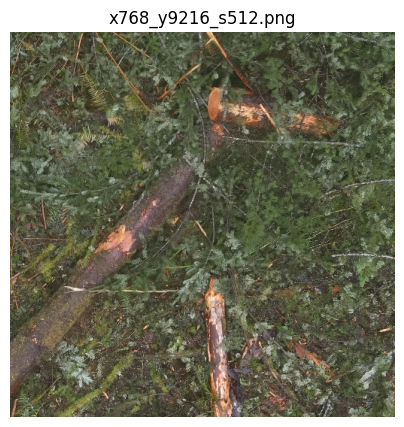

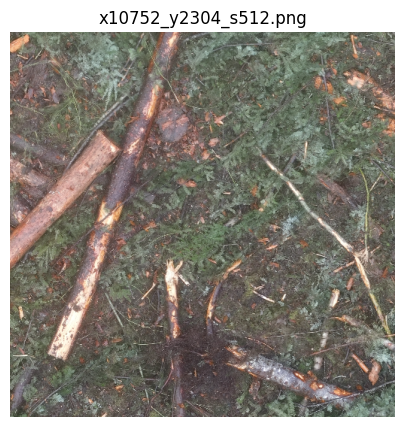

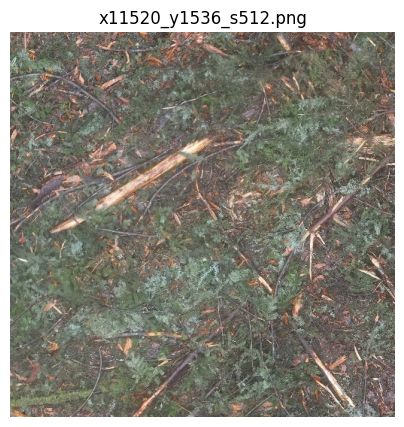

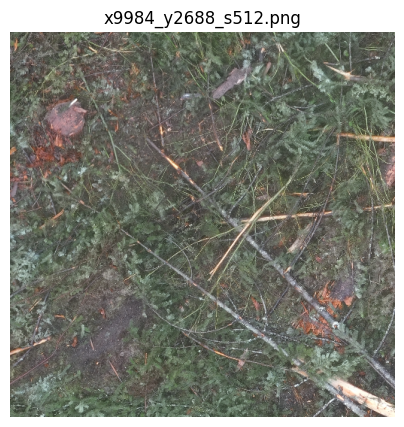

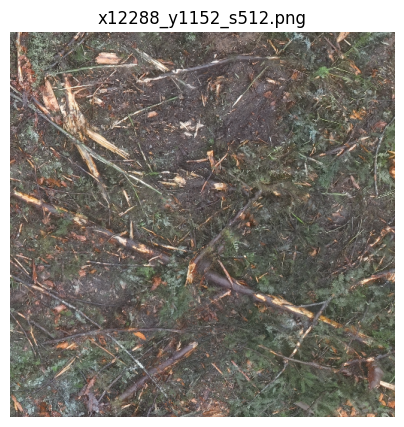

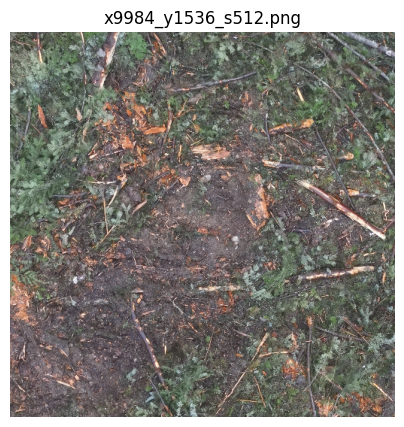

In [14]:
# 6 (optional) — Preview a few saved tiles

import random

tiles = list((OUT_DIR / "images").glob("*.png")) if OUTPUT_FORMAT.lower() == "png" else list((OUT_DIR / "images").glob("*.tif"))
print("Number of tiles:", len(tiles))

if plt is None:
    print("matplotlib not available; skipping preview.")
elif not tiles:
    print("No tiles saved.")
else:
    sample = random.sample(tiles, k=min(6, len(tiles)))
    for p in sample:
        if p.suffix.lower() == ".png":
            if Image is None:
                print("Pillow not available; cannot preview PNG.")
                break
            img = np.array(Image.open(p))
        else:
            with rasterio.open(p) as t:
                a = t.read()
                a8 = to_uint8_rgb(a)
                img = np.transpose(a8, (1, 2, 0))

        plt.figure(figsize=(5, 5))
        plt.imshow(img)
        plt.title(p.name)
        plt.axis("off")
        plt.show()
